# Almond Orchard Water Use 

## Numbers and examples


Include literature here and create an example

## Snippets of TECHNICAL REPORT - determining the water requirements of tree nut crops in the main production areas of Portugal
* The intensification of almond production in Portugal is a recent phenomenon, as the acreage of new intensive plantations has gone from less than 2.000 ha in 2014 to more than 26.000 ha in 2020. Irrigation is indispensable to achieve high productivity in Portugal. (maybe give a calculation)

* Methodology used: After determining ETc, the net irrigation requirements are computed based on the effective rainfall and the water
budget of the crop root zone. Such irrigation requirements are calculated for the different areas and for a period of 11 years over the last two decades to capture the temporal variability. They represent the net irrigation demand needed to achieve maximum production in an average year.

* Maximum Kc values are typically reached on July-August, ranging from 0.95 to 1.10. However, more recent data from California suggests that almond Kc maximum values of mature orchards irrigated with microsprinklers may reach values as high as 1.2 (Goldhamer & Girona, 2012). High Kc values, close to 1.2, have been also reported in Australia (Stevens et al., 2011). Higher Kc values are likely due to the increase in planting densities in recent plantations, larger tree canopies due to less annual pruning, and higher fruit loads. Additionally, more frequent soil wetting due to high-frequency irrigation can also increase direct soil surface evaporation which may also contribute to high Kc values. With this background, the almond crop coefficients used here are based on direct ETc field measurements conducted during 10 years in Córdoba, Spain, using a weighing lysimeter installed in 2009 (the only weighing lysimeter of almond in the world until recently), as reported in three consecutive doctoral theses (i.e., Espadafor, 2015; López-López, 2018 and Moldero, 2021).

```{figure} figures/crop_factors.PNG
---
height: 300px
name: directive-fig
---
Crop factors used
```
the optimal deficit irrigation program for almond should prioritize supplying the full ETc in the following periods:

1. Fruit set and early canopy growth (normally achieved if the winter had normal rainfall and the soil is fully charged at flowering)
2. Post-harvest period when the floral buds of the following season are formed. Normally, a month duration after harvest is considered minimum, then some water deficits may be applied later, as the end of the season approaches.
3. Severe water deficits should be always avoided; ETa should not be below 50% of ETc throughout the season.

```{figure} almond_irrigation_requirement.PNG
---
height: 300px
name: directive-fig
---
70 percent canopy over orchard (CC=70%) (López-López et al., 2018)
```


# What we will do here:
1. Estimate ETref/ETpot/ETact for case study fields
2. Get rainfall
3. Get irrigation quota (http://simulador.edia.pt/)
4. What do we see?

## Potential and Actual almond evaporation

I got some data from: https://data.apps.fao.org/wapor/?lang=en for Rota Única Farm 

* Daily Reference ET (df_ETref) -- daily, 30 km (I think it is Penmann Monteith)
* Dekadal ET, ETref, Precipitation (wondering if P is cumulative - otherwise it is pretty useless) -- dekadal, 300 m

In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import os
import seaborn as sns

# to pick it up fast where you left
df_ETref = pd.read_csv(os.path.join('Data/Evaporation','Ref_ET.csv'), index_col=0, header=0, names=['ETref'], delimiter=';', decimal=',')
df_ETref.index = pd.to_datetime(df_ETref.index)

print(df_ETref.head())


# to pick it up fast where you left
df_dek = pd.read_csv(os.path.join('Data/Evaporation','Wapor.csv'), index_col=0, header=0, names=["AETI","RET","PCP"], delimiter=';', decimal=',')
df_dek.index = pd.to_datetime(df_dek.index)

print(df_dek.head())

            ETref
2018-01-01    0.6
2018-01-02    0.6
2018-01-03    0.7
2018-01-04    0.6
2018-01-05    0.6
            AETI  RET  PCP
2018-01-01   0.3  0.7  2.5
2018-01-11   0.4  0.9  1.1
2018-01-21   0.6  1.2  2.3
2018-02-01   0.7  1.5  0.0
2018-02-11   0.9  1.5  0.0


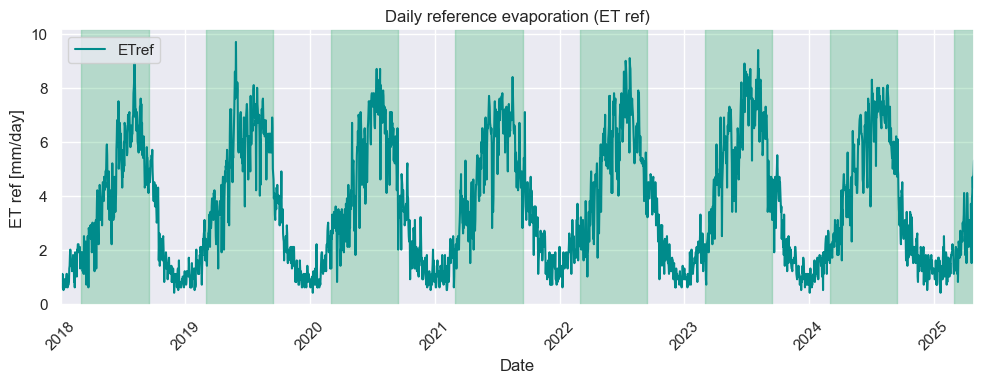

In [6]:
# === Plot NDVI time series with min/max around median ===
sns.set_theme()

fig, ax = plt.subplots(figsize=(10, 4))

df_ETref.plot(color='darkcyan', ax=ax)

# Loop through each year and color the background for March to September
for year in range(df_ETref.index.year.min(), df_ETref.index.year.max() + 1):
    start_date = pd.Timestamp(f'{year}-03-01')  # March 1st of the year
    end_date = pd.Timestamp(f'{year}-09-15')   # September 30th of the year
    ax.axvspan(start_date, end_date, color='mediumseagreen', alpha=0.3)

# Labels and legend
plt.title('Daily reference evaporation (ET ref)')
plt.xlabel('Date')
plt.ylabel('ET ref [mm/day]')
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()

# === Show plot ===
plt.show()

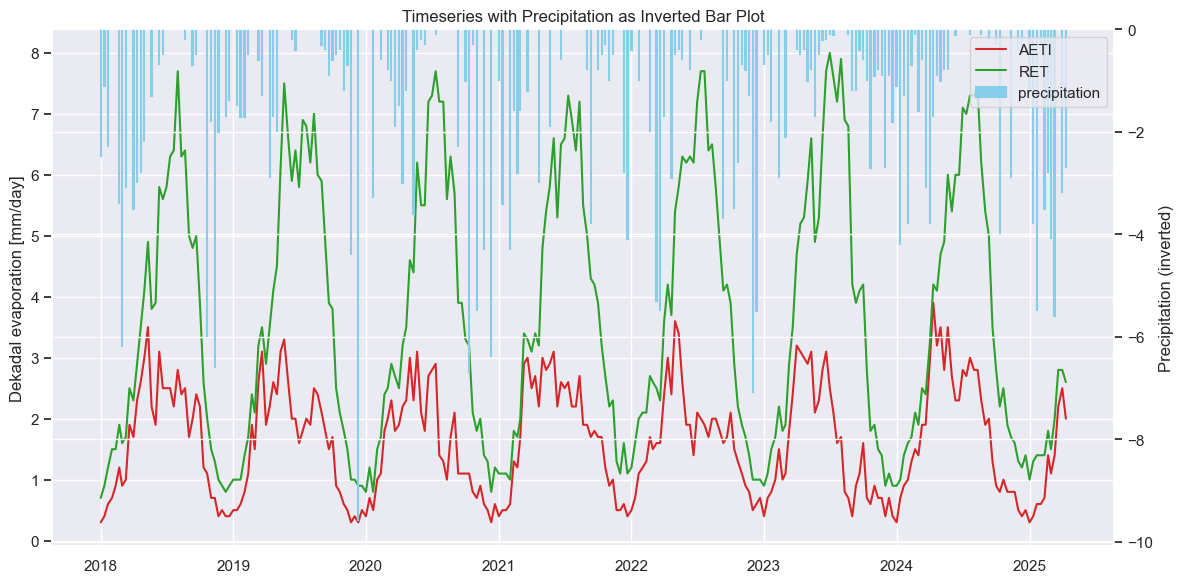

In [7]:
# === Plot NDVI time series with min/max around median ===
sns.set_theme()

# fig, ax = plt.subplots(figsize=(10, 4))

# df_dek.plot(ax=ax)



# # Labels and legend
# plt.title('Dekadal evaporation (ETref and AETI) and precipitation (PCP)')
# plt.xlabel('Date')
# plt.ylabel('Dekadal evaporation [mm/day]')
# plt.legend()
# plt.grid(True)
# plt.xticks(rotation=45)
# plt.tight_layout()

# # === Show plot ===
# plt.show()

# "","RET","PCP"

fig, ax1 = plt.subplots(figsize=(12, 6))

# Loop through each year and color the background for March to September
for year in range(df_dek.index.year.min(), df_dek.index.year.max() + 1):
    start_date = pd.Timestamp(f'{year}-03-01')  # March 1st of the year
    end_date = pd.Timestamp(f'{year}-09-15')   # September 30th of the year
    ax.axvspan(start_date, end_date, color='mediumseagreen', alpha=0.3)

# Line plots for 
ax1.plot(df_dek.index, df_dek['AETI'], color='tab:red', label='AETI')
ax1.plot(df_dek.index, df_dek['RET'], color='tab:green', label='RET')
ax1.set_ylabel('Dekadal evaporation [mm/day]')
# ax1.legend(loc='upper left')

# Secondary y-axis for Precipitation (plotted as a bar plot, top-down)
ax2 = ax1.twinx()
ax2.bar(df_dek.index, -df_dek['PCP'], color='skyblue', edgecolor='skyblue', linewidth=1.5, label='precipitation')
ax2.set_ylabel('Precipitation (inverted)')
# ax2.legend(loc='upper right')

# Optional: make sure the precipitation legend appears
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

plt.title('Timeseries with Precipitation as Inverted Bar Plot')
plt.tight_layout()
plt.show()

### Estimated Crop Factors

In [10]:
# to pick it up fast where you left
df_kc = pd.read_csv(os.path.join('Data/Evaporation','almond_crop_factors_portugal.csv'), index_col=0, header=0, names=['Kc'])

print(df_dek.head())

            AETI  RET  PCP
2018-01-01   0.3  0.7  2.5
2018-01-11   0.4  0.9  1.1
2018-01-21   0.6  1.2  2.3
2018-02-01   0.7  1.5  0.0
2018-02-11   0.9  1.5  0.0


In [16]:
# Define Kc values by month
kc_by_month = {
    1: 0.30,  2: 0.30,  3: 0.40,
    4: 0.60,  5: 0.80,  6: 0.90,
    7: 0.90,  8: 0.85,  9: 0.70,
    10: 0.50, 11: 0.30, 12: 0.30
}

# Add Kc values by mapping the month from the 'date' column
df_dek['Kc'] = df_dek.index.month.map(kc_by_month)

df_dek['PET'] = df_dek['RET'] * df_dek['Kc'] 
print(df_dek.head())

            AETI  RET  PCP   Kc   PET
2018-01-01   0.3  0.7  2.5  0.3  0.21
2018-01-11   0.4  0.9  1.1  0.3  0.27
2018-01-21   0.6  1.2  2.3  0.3  0.36
2018-02-01   0.7  1.5  0.0  0.3  0.45
2018-02-11   0.9  1.5  0.0  0.3  0.45


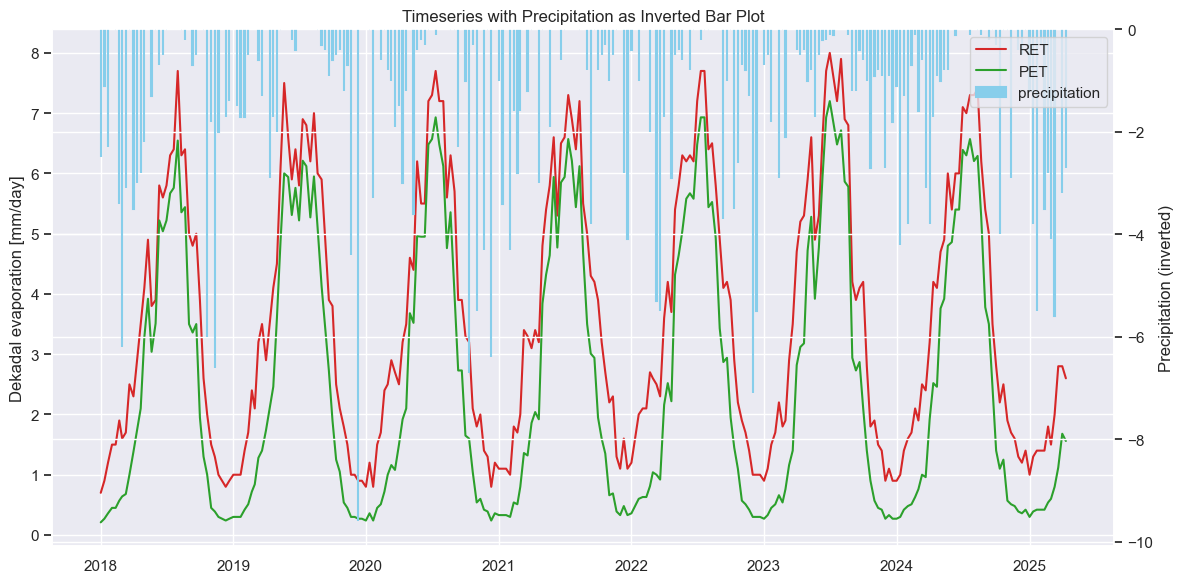

In [17]:
fig, ax1 = plt.subplots(figsize=(12, 6))

# Loop through each year and color the background for March to September
for year in range(df_dek.index.year.min(), df_dek.index.year.max() + 1):
    start_date = pd.Timestamp(f'{year}-03-01')  # March 1st of the year
    end_date = pd.Timestamp(f'{year}-09-15')   # September 30th of the year
    ax.axvspan(start_date, end_date, color='mediumseagreen', alpha=0.3)

# Line plots for 
ax1.plot(df_dek.index, df_dek['RET'], color='tab:red', label='RET')
ax1.plot(df_dek.index, df_dek['PET'], color='tab:green', label='PET')
ax1.set_ylabel('Dekadal evaporation [mm/day]')
# ax1.legend(loc='upper left')

# Secondary y-axis for Precipitation (plotted as a bar plot, top-down)
ax2 = ax1.twinx()
ax2.bar(df_dek.index, -df_dek['PCP'], color='skyblue', edgecolor='skyblue', linewidth=1.5, label='precipitation')
ax2.set_ylabel('Precipitation (inverted)')
# ax2.legend(loc='upper right')

# Optional: make sure the precipitation legend appears
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper right')

plt.title('Timeseries with Precipitation as Inverted Bar Plot')
plt.tight_layout()
plt.show()

In [27]:
# water deficit:
df_dek['Irrigation requirement'] = df_dek['PET'] - df_dek['PCP']

df_dek[df_dek['Irrigation requirement']<0] = 0
print(df_dek.head())

            AETI  RET  PCP   Kc   PET  Irrigation requirement  year  month
2018-01-01   0.0  0.0  0.0  0.0  0.00                    0.00  2018      1
2018-01-11   0.0  0.0  0.0  0.0  0.00                    0.00  2018      1
2018-01-21   0.0  0.0  0.0  0.0  0.00                    0.00  2018      1
2018-02-01   0.7  1.5  0.0  0.3  0.45                    0.45  2018      2
2018-02-11   0.9  1.5  0.0  0.3  0.45                    0.45  2018      2


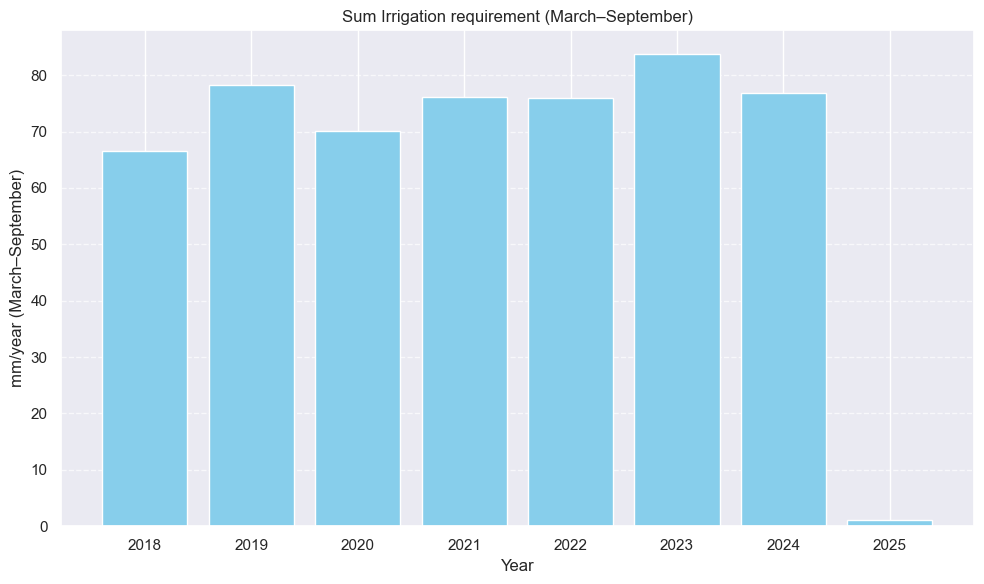

In [29]:
# Extract year and month
df_dek['year'] = df_dek.index.year
df_dek['month'] = df_dek.index.month

# Filter for months March (3) to September (9)
df_filtered = df_dek[(df_dek['month'] >= 3) & (df_dek['month'] <= 10)]

# Group by year and sum values
yearly_sums = df_filtered.groupby('year')['Irrigation requirement'].sum().reset_index()

# Plot as barplot
plt.figure(figsize=(10, 6))
plt.bar(yearly_sums['year'], yearly_sums['Irrigation requirement'], color='skyblue')
plt.xlabel('Year')
plt.ylabel('mm/year (March–September)')
plt.title('Sum Irrigation requirement (March–September)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()